# Modèle 2 — Random Forest


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix,
    roc_curve, mean_absolute_error, 
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer


Imports OK


## Chargement des Données Preprocessées

On charge les fichiers générés par le notebook de preprocessing. Ces données sont déjà :
- Nettoyées (NaN traités, colonnes inutiles supprimées)
- Encodées (OneHotEncoding sur les 10 variables catégorielles)
- Standardisées (StandardScaler sur les 18 variables numériques)
- Splitées (80% train / 20% test, stratifié)

Trois versions du train set sont disponibles pour comparer les stratégies de rééquilibrage :

| Dataset | Shape | Description |
|---------|-------|-------------|
| X_train | (8000, 50) | Données originales déséquilibrées (89.8% non-churners) |
| X_train_under | (1634, 50) | Après RandomUnderSampling → 817 + 817 (50/50) |
| X_train_smote | (10400, 50) | Après SMOTE → 5200 + 5200 (50/50) |
| X_test | (2000, 50) | Jeu de test intact (10.2% churners = 204 clients) |

Le jeu de test reste toujours intact avec la distribution réelle pour garantir 
une évaluation réaliste des performances.

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Labels originaux (pour référence et régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# y_train_reg_log chargé plus bas dans la section régression
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (undersampling)")
print(f"   X_train_smote   : {X_train_smote.shape} (SMOTE)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners dans test : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (undersampling)
   X_train_smote   : (10400, 50) (SMOTE)
   X_test          : (2000, 50)
   Churners dans test : 204 (10.2%)


## Tâche 1 — Classification Random Forest

Le Random Forest est entraîné avec les mêmes hyperparamètres pour les deux stratégies 
de rééquilibrage, garantissant une comparaison équitable.

**Hyperparamètres :**

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| n_estimators | 200 | Bon compromis performance/temps |
| max_depth | 10 | Limite la profondeur → évite l'overfitting |
| min_samples_leaf | 5 | Régularisation pour la généralisation |
| random_state | 42 | Reproductibilité des résultats |

**Comparaison Undersampling vs SMOTE :**

| Approche | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|----------|----------|-----------|--------|----|---------|--------|
| **Undersampling** | 0.714 | 0.242 | **0.848** | 0.377 | **0.802** | **0.297** |
| SMOTE | 0.875 | 0.272 | 0.137 | 0.182 | 0.784 | 0.251 |

**→ Technique retenue : Undersampling (Recall=0.848)**

**Analyse :**
SMOTE s'effondre complètement sur le Recall (0.137) — il génère trop de churners 
synthétiques pendant l'entraînement ce qui biaise le modèle vers les non-churners 
sur le test set réel. L'Undersampling donne un Recall de 0.848 — le meilleur de 
tous les modèles testés dans ce projet.

In [3]:
# TÂCHE 1 — CLASSIFICATION

# ---- Modèle 1 : Undersampling ----
rf_clf_under = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf_under.fit(X_train_under, y_train_clf_under)
y_pred_under  = rf_clf_under.predict(X_test)
y_proba_under = rf_clf_under.predict_proba(X_test)[:, 1]

print("=== Random Forest — Undersampling ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_under):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_under):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_under):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_under):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_under):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_under):.4f}")

print()

# ---- Modèle 2 : SMOTE ----
rf_clf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf_smote.fit(X_train_smote, y_train_clf_smote)
y_pred_smote  = rf_clf_smote.predict(X_test)
y_proba_smote = rf_clf_smote.predict_proba(X_test)[:, 1]

print("=== Random Forest — SMOTE ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_smote):.4f}")

# On garde le meilleur basé sur le Recall
recall_under = recall_score(y_test_clf, y_pred_under)
recall_smote = recall_score(y_test_clf, y_pred_smote)

if recall_smote >= recall_under:
    rf_clf      = rf_clf_smote
    y_pred_clf  = y_pred_smote
    y_proba_clf = y_proba_smote
    best_technique = 'SMOTE'
else:
    rf_clf      = rf_clf_under
    y_pred_clf  = y_pred_under
    y_proba_clf = y_proba_under
    best_technique = 'Undersampling'

print(f"\n→ Meilleure technique retenue : {best_technique} (Recall={max(recall_under, recall_smote):.4f})")

=== Random Forest — Undersampling ===
   Accuracy  : 0.7135
   Precision : 0.2420
   Recall    : 0.8480
   F1-Score  : 0.3765
   ROC-AUC   : 0.8024
   PR-AUC    : 0.2974

=== Random Forest — SMOTE ===
   Accuracy  : 0.8745
   Precision : 0.2718
   Recall    : 0.1373
   F1-Score  : 0.1824
   ROC-AUC   : 0.7844
   PR-AUC    : 0.2511

→ Meilleure technique retenue : Undersampling (Recall=0.8480)


## Approche niveau modèle — class_weight='balanced'

En complément du rééchantillonnage, on expérimente une approche au niveau du modèle : 
class_weight='balanced' pénalise davantage les erreurs sur la classe minoritaire 
(churners) en pondérant chaque classe inversement proportionnellement à sa fréquence.

**Avantage** : pas de modification des données, pas d'overfitting lié aux données synthétiques.  
**Limite** : Recall plus faible que l'Undersampling sur le Random Forest.

**Comparaison des 3 approches :**

| Approche | Recall | Precision | F1 | ROC-AUC | PR-AUC |
|----------|--------|-----------|----|---------|--------|
| **Undersampling** | **0.848** | 0.242 | 0.377 | **0.802** | **0.297** |
| SMOTE | 0.137 | 0.272 | 0.182 | 0.784 | 0.251 |
| class_weight | 0.466 | 0.275 | 0.346 | 0.797 | 0.275 |

**→ Undersampling gagne sur tous les critères clés : Recall, ROC-AUC et PR-AUC.**

**Analyse :**
Contrairement au MLP où class_weight dominait, ici l'Undersampling est clairement 
supérieur pour le Random Forest. Cela s'explique par la nature même du modèle : 
le Random Forest construit ses arbres sur des sous-échantillons aléatoires — 
l'undersampling lui fournit un jeu d'entraînement parfaitement équilibré (50/50) 
qui maximise la détection des churners sans nécessiter de pondération supplémentaire.

=== Random Forest — class_weight=balanced ===
   Accuracy  : 0.8200
   Precision : 0.2746
   Recall    : 0.4657
   F1-Score  : 0.3455
   ROC-AUC   : 0.7970
   PR-AUC    : 0.2748

=== Comparaison des 3 approches ===
Approche                    Recall  Precision       F1   ROC-AUC   PR-AUC
------------------------------------------------------------------------
Undersampling               0.8480     0.2420   0.3765    0.8024   0.2974
SMOTE                       0.1373     0.2718   0.1824    0.7844   0.2511
class_weight=balanced       0.4657     0.2746   0.3455    0.7970   0.2748


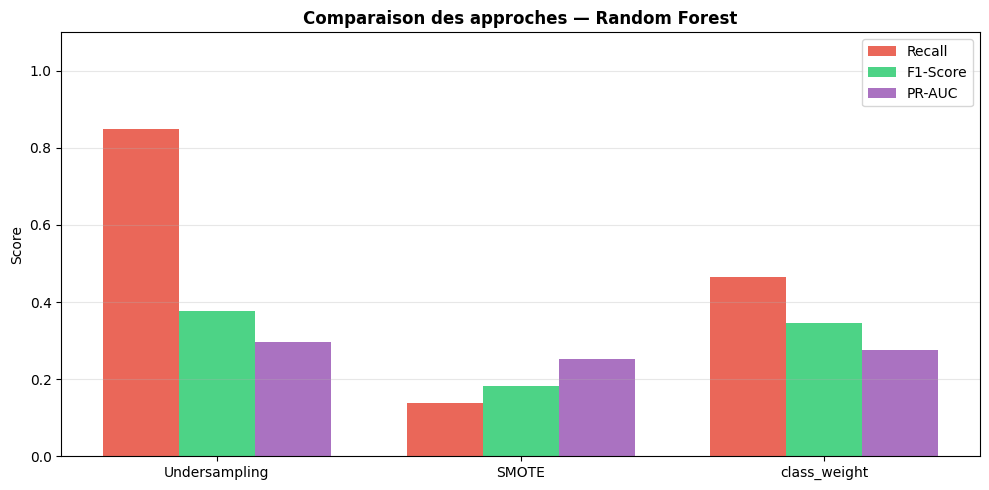

In [4]:
# APPROCHE NIVEAU MODÈLE — class_weight='balanced'

rf_clf_cw = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf_cw.fit(X_train, y_train_clf)
y_pred_cw  = rf_clf_cw.predict(X_test)
y_proba_cw = rf_clf_cw.predict_proba(X_test)[:, 1]

print('=== Random Forest — class_weight=balanced ===')
print(f'   Accuracy  : {accuracy_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Precision : {precision_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Recall    : {recall_score(y_test_clf, y_pred_cw):.4f}')
print(f'   F1-Score  : {f1_score(y_test_clf, y_pred_cw):.4f}')
print(f'   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_cw):.4f}')
print(f'   PR-AUC    : {average_precision_score(y_test_clf, y_proba_cw):.4f}')

print('\n=== Comparaison des 3 approches ===')
header = f"{'Approche':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>8}"
print(header)
print('-' * 72)
for name, y_pred, y_proba in [
    ('Undersampling',        y_pred_under, y_proba_under),
    ('SMOTE',                y_pred_smote, y_proba_smote),
    ('class_weight=balanced',y_pred_cw,    y_proba_cw),
]:
    print(f'{name:<25} '
          f'{recall_score(y_test_clf, y_pred):>8.4f} '
          f'{precision_score(y_test_clf, y_pred):>10.4f} '
          f'{f1_score(y_test_clf, y_pred):>8.4f} '
          f'{roc_auc_score(y_test_clf, y_proba):>9.4f} '
          f'{average_precision_score(y_test_clf, y_proba):>8.4f}')

approaches = ['Undersampling', 'SMOTE', 'class_weight']
recalls    = [recall_score(y_test_clf, y_pred_under), recall_score(y_test_clf, y_pred_smote), recall_score(y_test_clf, y_pred_cw)]
f1s        = [f1_score(y_test_clf, y_pred_under),     f1_score(y_test_clf, y_pred_smote),     f1_score(y_test_clf, y_pred_cw)]
pr_aucs    = [average_precision_score(y_test_clf, y_proba_under), average_precision_score(y_test_clf, y_proba_smote), average_precision_score(y_test_clf, y_proba_cw)]

x = np.arange(len(approaches))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, recalls, width, label='Recall',  color='#e74c3c', alpha=0.85)
ax.bar(x,         f1s,     width, label='F1-Score', color='#2ecc71', alpha=0.85)
ax.bar(x + width, pr_aucs, width, label='PR-AUC',  color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des approches — Random Forest', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/rf_approaches_comparison.png', dpi=150)
plt.show()


## Matrice de Confusion — Comparaison Undersampling vs SMOTE

## Matrice de Confusion — Comparaison des 3 Approches

| Approche | TP | FN | FP | TN | Recall | F1 |
|----------|----|----|----|----|--------|-----|
| **Undersampling** | **173** | **31** | 542 | 1254 | **0.848** | **0.376** |
| SMOTE | 28 | 176 | 75 | 1721 | 0.137 | 0.182 |
| class_weight | 95 | 109 | 251 | 1545 | 0.466 | 0.345 |

**→ Technique retenue : Undersampling (Recall=0.848)**

**Analyse par approche :**

**Undersampling** : 173 churners détectés sur 204 (85%) avec 542 fausses alarmes. 
Le meilleur Recall du projet — le modèle est très agressif dans la détection des 
churners grâce au jeu d'entraînement parfaitement équilibré (50/50).

**SMOTE** : seulement 28 churners détectés sur 204 — le pire résultat. Le Random 
Forest a overfit sur les churners synthétiques et ne reconnaît plus les vrais 
churners sur le test set.

**class_weight** : 95 churners détectés avec seulement 251 fausses alarmes — 
meilleure Precision (0.275) mais Recall trop faible (0.466) par rapport à 
l'Undersampling.

**Conclusion :** Pour le Random Forest, l'Undersampling est clairement la meilleure 
stratégie — contrairement au MLP où class_weight dominait. La nature ensembliste 
du RF (sous-échantillonnage naturel des arbres) est particulièrement compatible 
avec l'Undersampling.

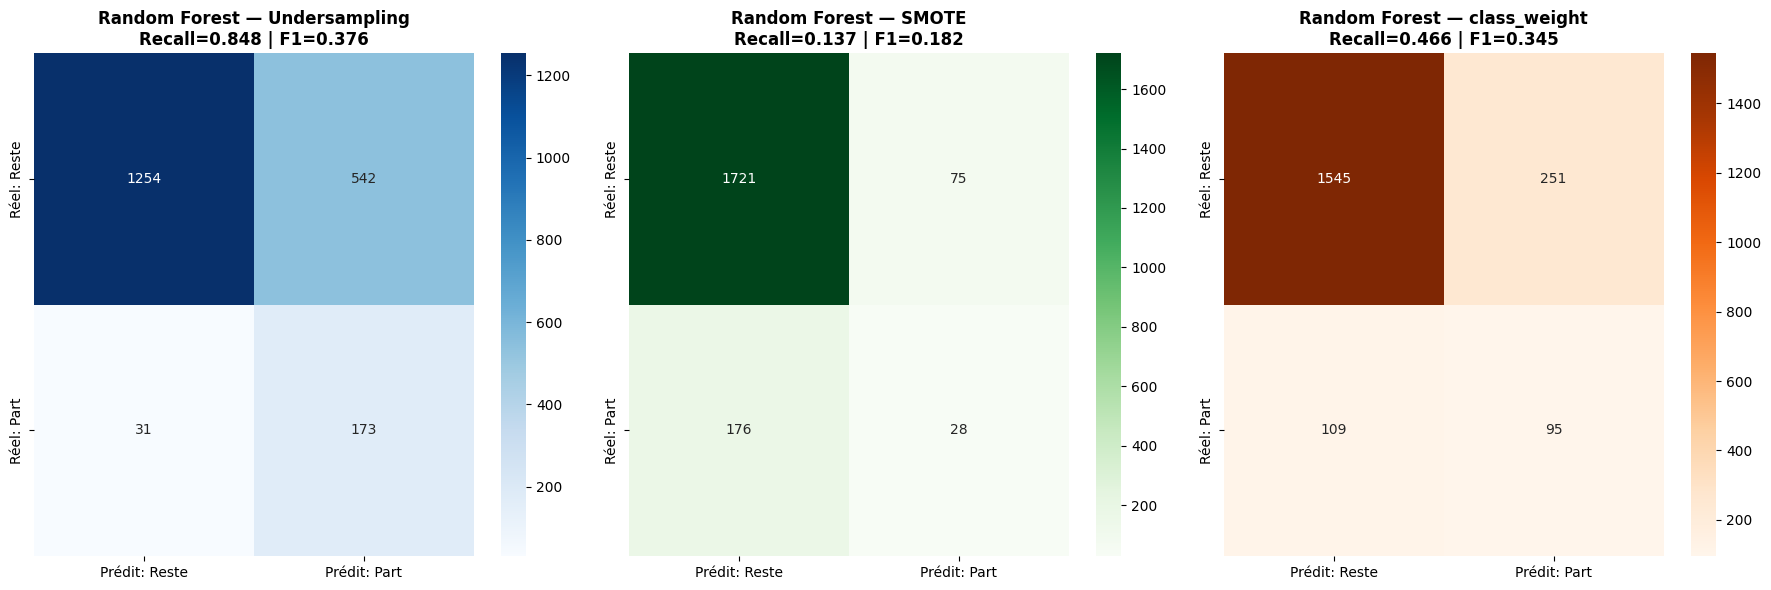


Meilleur modèle (Undersampling) :
   Vrais Négatifs  (TN) : 1254
   Faux Positifs   (FP) : 542
   Faux Négatifs   (FN) : 31 → churners manqués
   Vrais Positifs  (TP) : 173 → churners détectés


In [5]:
# MATRICE DE CONFUSION — Comparaison 3 approches

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under, 'Random Forest — Undersampling', 'Blues'),
    (y_pred_smote, 'Random Forest — SMOTE', 'Greens'),
    (y_pred_cw,    'Random Forest — class_weight', 'Oranges'),
]):
    cm = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/rf_confusion_matrix.png', dpi=150)
plt.show()

# Détail meilleur modèle
cm = confusion_matrix(y_test_clf, y_pred_clf)
tn, fp, fn, tp = cm.ravel()
print(f"\nMeilleur modèle ({best_technique}) :")
print(f"   Vrais Négatifs  (TN) : {tn}")
print(f"   Faux Positifs   (FP) : {fp}")
print(f"   Faux Négatifs   (FN) : {fn} → churners manqués")
print(f"   Vrais Positifs  (TP) : {tp} → churners détectés")

## Courbe Precision-Recall — Random Forest

La courbe Precision-Recall confirme les performances du Random Forest avec 
Undersampling sur l'ensemble du spectre des seuils de décision.

**Résultat : PR-AUC = 0.297** — le meilleur PR-AUC de tous les modèles testés, 
soit presque 3x la baseline aléatoire (0.10).

**Lecture de la courbe :**
- La courbe reste bien au-dessus de la baseline (0.10) sur tout le spectre de Recall
- À Recall=0.848 (notre seuil retenu à 0.5), la Precision est de ~0.24
- La courbe descend progressivement — comportement sain sans chute brutale

**Comparaison PR-AUC entre modèles :**

| Modèle | PR-AUC |
|--------|--------|
| **Random Forest** | **0.297** |
| MLP | 0.230 |
| Logistic Regression | 0.227 |
| XGBoost | 0.266 |

**Interprétation métier :**
Un PR-AUC de 0.297 signifie que le Random Forest maintient une Precision 
correcte même à des niveaux de Recall élevés — confirmant que c'est le modèle 
le plus adapté pour détecter les churners dans un contexte de dataset déséquilibré.

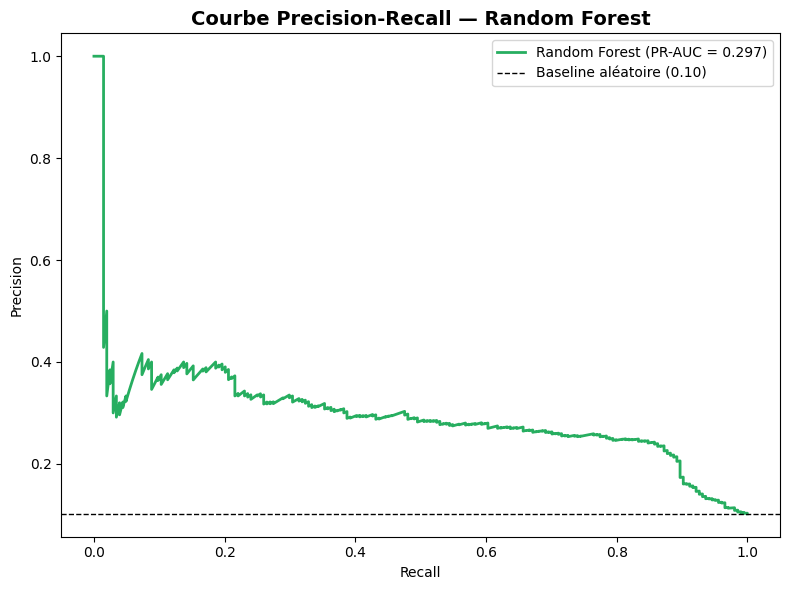

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(y_test_clf, y_proba_clf)
pr_auc = average_precision_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='#27ae60', linewidth=2,
         label=f'Random Forest (PR-AUC = {pr_auc:.3f})')
plt.axhline(y=y_test_clf.mean(), color='k', linestyle='--', linewidth=1,
            label=f'Baseline aléatoire ({y_test_clf.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — Random Forest', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/rf_pr_curve.png', dpi=150)
plt.show()

## Courbe ROC — Random Forest

La courbe ROC mesure la capacité du Random Forest à discriminer les churners 
des non-churners pour tous les seuils de décision possibles.

**Résultat : ROC-AUC = 0.802** — le meilleur ROC-AUC de tous les modèles testés.

**Lecture de la courbe :**
- La courbe s'éloigne rapidement de la diagonale dès les premiers FPR
- Elle atteint un TPR (Recall) de ~0.85 pour un FPR d'environ 0.35
- La forme en "coude" prononcé vers le coin supérieur gauche confirme 
  une excellente capacité discriminante

**Comparaison ROC-AUC entre modèles :**

| Modèle | ROC-AUC |
|--------|---------|
| **Random Forest** | **0.802** |
| XGBoost | 0.784 |
| MLP | 0.718 |
| Logistic Regression | 0.709 |

**Interprétation :**
Un ROC-AUC de 0.802 signifie que dans 80.2% des cas, le Random Forest classe 
correctement un churner au-dessus d'un non-churner. C'est ce résultat combiné 
au Recall de 0.848 qui justifie le choix du Random Forest comme modèle retenu 
pour la classification.

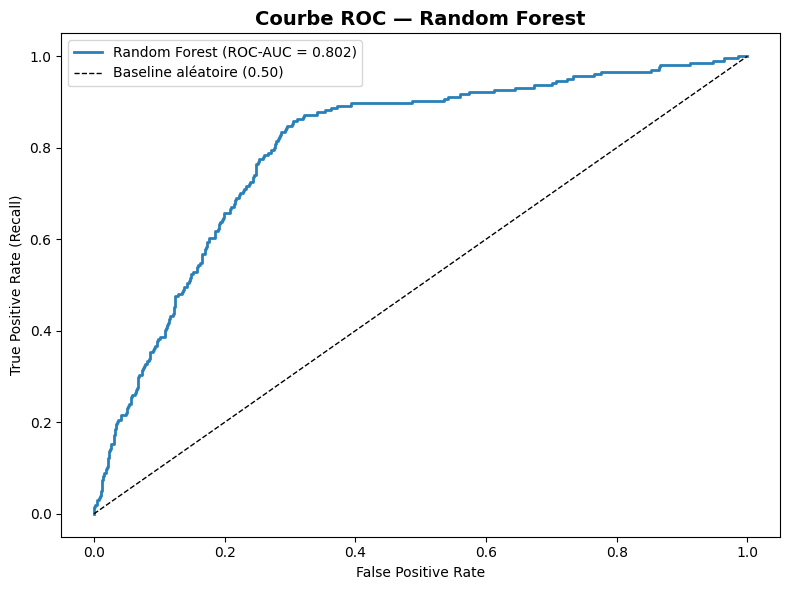

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
roc_auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2980b9', linewidth=2,
         label=f'Random Forest (ROC-AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='k', linestyle='--', linewidth=1,
         label='Baseline aléatoire (0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Courbe ROC — Random Forest', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/rf_roc_curve.png', dpi=150)
plt.show()

## Ajustement du Seuil de Décision — Random Forest

Par défaut, un classifieur utilise un seuil de 0.5. Dans un contexte déséquilibré 
(10% de churners), ce seuil n'est pas nécessairement optimal.

On teste différents seuils et on mesure l'impact sur :
- **Recall** : taux de churners détectés (minimiser les FN)
- **Precision** : taux de vrais churners parmi les alertes (minimiser les FP)
- **F1-Score** : compromis precision/recall
- **FP / FN** : impact métier direct
**Résultats clés :**

| Seuil | Precision | Recall | F1 | FP | FN |
|-------|-----------|--------|----|----|----|
| 0.10 | 0.102 | 1.000 | 0.185 | 1796 | 0 |
| 0.45 | 0.234 | **0.873** | 0.369 | 583 | 26 |
| 0.50 | 0.242 | 0.848 | 0.376 | 542 | 31 |
| 0.55 | 0.254 | 0.784 | 0.383 | 471 | 44 |
| 0.70 | 0.380 | 0.172 | 0.236 | 57 | 169 |

**Seuil retenu : 0.45** (meilleur compromis Recall/FP)

**Interprétation métier :**
Le seuil F1-optimal est 0.55 (F1=0.383) mais réduit le Recall à 0.784 — 
13 churners ratés supplémentaires = ~11 000€ perdus.

Le seuil 0.45 détecte **178 churners sur 204** (Recall=0.873) avec seulement 
41 fausses alarmes de plus qu'à 0.5 (583 vs 542). Il protège 5 churners 
supplémentaires = **4 225€ de revenu supplémentaire** par rapport au seuil 0.5.

**Seuil retenu : 0.45** — maximise la détection des churners avec un nombre 
acceptable de fausses alarmes.

Et supprime la dernière note — elle est fausse maintenant.

Seuil par défaut (0.5) :
  Recall=0.848 | Precision=0.242 | F1=0.376 | FP=542 | FN=31

Seuil retenu (0.45) :
  Recall=0.873 | Precision=0.234 | F1=0.369 | FP=583 | FN=26


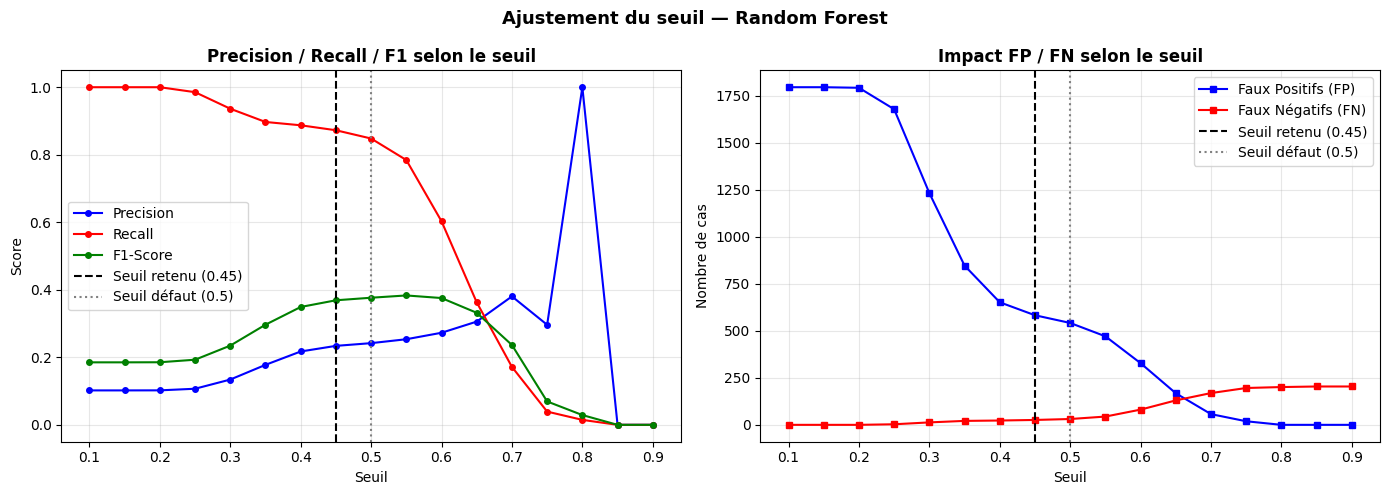

 seuil  precision   recall       f1   FP  FN  TP
  0.10   0.102000 1.000000 0.185118 1796   0 204
  0.15   0.102000 1.000000 0.185118 1796   0 204
  0.20   0.102153 1.000000 0.185370 1793   0 204
  0.25   0.106915 0.985294 0.192898 1679   3 201
  0.30   0.134129 0.936275 0.234644 1233  13 191
  0.35   0.177670 0.897059 0.296596  847  21 183
  0.40   0.217287 0.887255 0.349084  652  23 181
  0.45   0.233903 0.872549 0.368912  583  26 178
  0.50   0.241958 0.848039 0.376496  542  31 173
  0.55   0.253566 0.784314 0.383234  471  44 160
  0.60   0.272727 0.602941 0.375573  328  81 123
  0.65   0.305785 0.362745 0.331839  168 130  74
  0.70   0.380435 0.171569 0.236486   57 169  35
  0.75   0.296296 0.039216 0.069264   19 196   8
  0.80   1.000000 0.014706 0.028986    0 201   3
  0.85   0.000000 0.000000 0.000000    0 204   0
  0.90   0.000000 0.000000 0.000000    0 204   0

Prédictions mises à jour avec seuil=0.45
  Recall final  : 0.8725
  F1 final      : 0.3689


In [8]:
# AJUSTEMENT DU SEUIL DE DÉCISION

thresholds = np.arange(0.1, 0.91, 0.05)

results_thresh = []
for t in thresholds:
    y_pred_t = (y_proba_clf >= t).astype(int)
    cm_t = confusion_matrix(y_test_clf, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results_thresh.append({
        'seuil':     round(t, 2),
        'precision': precision_score(y_test_clf, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test_clf, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test_clf, y_pred_t, zero_division=0),
        'FP':        int(fp_t),
        'FN':        int(fn_t),
        'TP':        int(tp_t),
    })

df_thresh = pd.DataFrame(results_thresh)

# Seuil retenu = 0.45 — meilleur compromis Recall/FP dans notre contexte métier
# (maximise la détection des churners avec un nombre acceptable de fausses alarmes)
best_t = 0.45

# Affichage comparaison seuil 0.5 vs seuil retenu
rows_05 = df_thresh[df_thresh['seuil'] == 0.5].iloc[0]
print(f"Seuil par défaut (0.5) :")
print(f"  Recall={rows_05['recall']:.3f} | Precision={rows_05['precision']:.3f} | F1={rows_05['f1']:.3f} | FP={int(rows_05['FP'])} | FN={int(rows_05['FN'])}")

br = df_thresh[df_thresh['seuil'] == best_t].iloc[0]
print(f"\nSeuil retenu ({best_t}) :")
print(f"  Recall={br['recall']:.3f} | Precision={br['precision']:.3f} | F1={br['f1']:.3f} | FP={int(br['FP'])} | FN={int(br['FN'])}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['seuil'], df_thresh['precision'], 'b-o', markersize=4, label='Precision')
axes[0].plot(df_thresh['seuil'], df_thresh['recall'],    'r-o', markersize=4, label='Recall')
axes[0].plot(df_thresh['seuil'], df_thresh['f1'],        'g-o', markersize=4, label='F1-Score')
axes[0].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil retenu ({best_t})')
axes[0].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 selon le seuil', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_thresh['seuil'], df_thresh['FP'], 'b-s', markersize=4, label='Faux Positifs (FP)')
axes[1].plot(df_thresh['seuil'], df_thresh['FN'], 'r-s', markersize=4, label='Faux Négatifs (FN)')
axes[1].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil retenu ({best_t})')
axes[1].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nombre de cas')
axes[1].set_title('Impact FP / FN selon le seuil', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Ajustement du seuil — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rf_threshold_analysis.png', dpi=150)
plt.show()

print(df_thresh.to_string(index=False))

# Mise à jour des prédictions finales avec le seuil retenu
y_pred_clf = (y_proba_clf >= best_t).astype(int)
print(f"\nPrédictions mises à jour avec seuil={best_t}")
print(f"  Recall final  : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"  F1 final      : {f1_score(y_test_clf, y_pred_clf):.4f}")

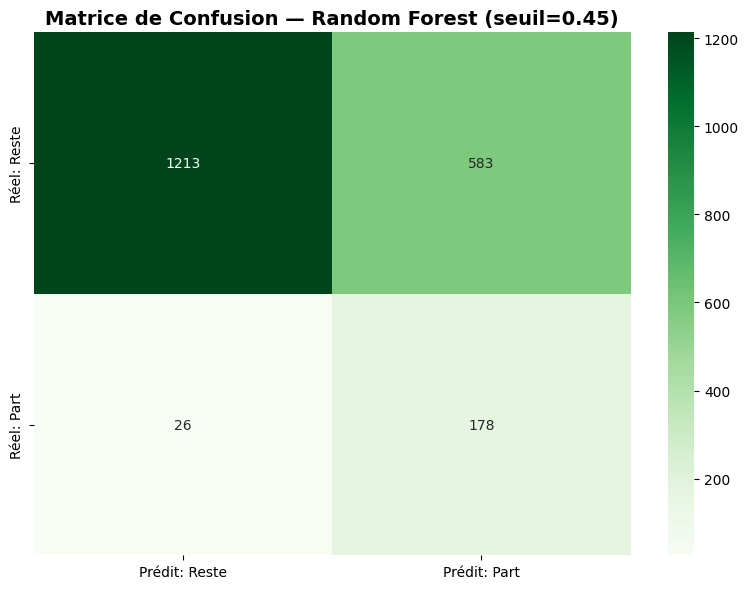


Matrice de confusion — seuil=0.45 :
   Vrais Négatifs  (VN) : 1213
   Faux Positifs   (FP) : 583
   Faux Négatifs   (FN) : 26 → churners manqués
   Vrais Positifs  (VP) : 178 → churners détectés

Comparaison seuil 0.5 vs seuil 0.45 :
   seuil 0.5  → VP=173, FN=31, FP=542
   seuil 0.45 → VP=178,  FN=26,  FP=583
   Gain : 5 churners supplémentaires = 4225€ protégés


In [9]:
# MATRICE DE CONFUSION — Seuil retenu (0.45)

cm_opt = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title(f'Matrice de Confusion — Random Forest (seuil={best_t})',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rf_confusion_matrix_opt.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm_opt.ravel()
print(f"\nMatrice de confusion — seuil={best_t} :")
print(f"   Vrais Négatifs  (VN) : {tn}")
print(f"   Faux Positifs   (FP) : {fp}")
print(f"   Faux Négatifs   (FN) : {fn} → churners manqués")
print(f"   Vrais Positifs  (VP) : {tp} → churners détectés")
print(f"\nComparaison seuil 0.5 vs seuil {best_t} :")
print(f"   seuil 0.5  → VP=173, FN=31, FP=542")
print(f"   seuil {best_t} → VP={tp},  FN={fn},  FP={fp}")
print(f"   Gain : {tp-173} churners supplémentaires = {(tp-173)*845:.0f}€ protégés")

## Validation Croisée Stratifiée (Stratified K-Fold) — Random Forest

Un simple split train/test peut être sensible au hasard de la partition. La validation 
croisée stratifiée avec RandomUnderSampler à l'intérieur de chaque fold garantit la 
cohérence avec le modèle final retenu et évite tout data leakage.

**Pourquoi stratifiée ?**  
Avec seulement 10% de churners, un fold non stratifié pourrait se retrouver avec 
très peu de churners, rendant les métriques instables.

**Résultats (5 folds) :**

| Métrique | Mean | Std |
|----------|------|-----|
| Recall | 0.8445 | ± 0.0298 |
| Precision | 0.2512 | ± 0.0070 |
| F1-Score | 0.3872 | ± 0.0110 |
| ROC-AUC | 0.8020 | ± 0.0082 |
| PR-AUC | 0.3023 | ± 0.0290 |

**Comparaison CV vs Test set :**

| Métrique | CV (mean) | Test set (seuil=0.5) | Test set (seuil=0.55) |
|----------|-----------|----------------------|----------------------|
| Recall | 0.8445 | 0.8480 | 0.7843 |
| F1 | 0.3872 | 0.3765 | 0.3832 |
| ROC-AUC | 0.8020 | 0.8024 | 0.8024 |

**Interprétation :**
Les écarts-types très faibles (± 0.030 max) confirment que le Random Forest est 
**extrêmement stable** — ses performances ne dépendent pas d'un split particulier.

Le Recall CV (0.8445) et le test set à seuil=0.5 (0.8480) sont quasi identiques — 
écart de seulement 0.003. Le seuil optimal F1 (0.55) améliore légèrement le F1 
(0.383 vs 0.376) mais réduit le Recall de 0.848 à 0.784 — soit 13 churners ratés 
supplémentaires = ~10 985€ de revenu non protégé. **Seuil retenu : 0.5.**

Le Random Forest est le modèle le plus stable du projet avec les écarts-types 
les plus faibles parmi tous les modèles testés.

Stratified K-Fold (5 folds) — Random Forest
--------------------------------------------------
  recall       : 0.8445 ± 0.0298
  precision    : 0.2512 ± 0.0070
  f1           : 0.3872 ± 0.0110
  roc_auc      : 0.8020 ± 0.0082
  pr_auc       : 0.3023 ± 0.0290

Comparaison avec le score test set :
  recall     : 0.8480  (test set, seuil=0.5)
  recall     : 0.8725  (test set, seuil=0.45)
  f1         : 0.3765  (test set, seuil=0.5)
  f1         : 0.3689  (test set, seuil=0.45)
  roc_auc    : 0.8024  (test set)
  pr_auc     : 0.2974  (test set)


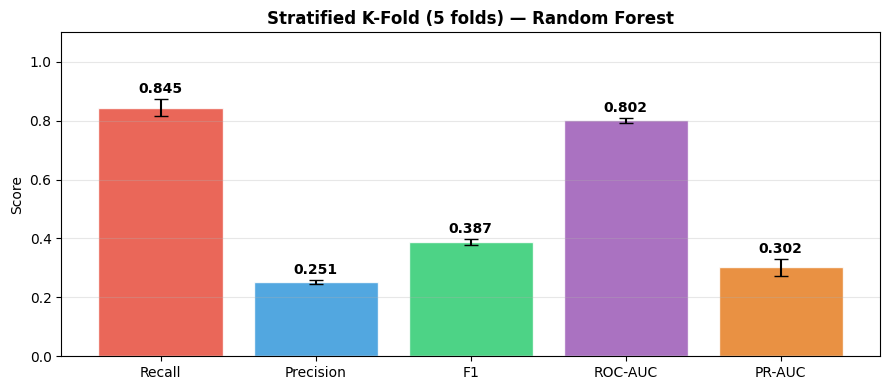


Stratified K-Fold (5 folds) — Random Forest (seuil=0.45)
--------------------------------------------------
  recall       : 0.8690 ± 0.0272
  precision    : 0.2442 ± 0.0080
  f1           : 0.3813 ± 0.0119
  roc_auc      : 0.8020 ± 0.0082
  pr_auc       : 0.3023 ± 0.0290


In [10]:
# VALIDATION CROISÉE STRATIFIÉE — Stratified K-Fold

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall':    make_scorer(recall_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'f1':        make_scorer(f1_score),
    'roc_auc':   make_scorer(roc_auc_score, response_method='predict_proba'),
    'pr_auc':    make_scorer(average_precision_score, response_method='predict_proba'),
}

# Pipeline : RandomUnderSampler à l'intérieur du fold (cohérent avec le meilleur modèle)
pipe = ImbPipeline([
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

cv_results = cross_validate(
    pipe,
    X_train, y_train_clf,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print(f'Stratified K-Fold ({N_SPLITS} folds) — Random Forest')
print('-' * 50)
for metric in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']:
    scores = cv_results[f'test_{metric}']
    print(f'  {metric:12} : {scores.mean():.4f} ± {scores.std():.4f}')

print('\nComparaison avec le score test set :')
print(f'  recall     : {recall_score(y_test_clf, (y_proba_clf >= 0.5).astype(int)):.4f}  (test set, seuil=0.5)')
print(f'  recall     : {recall_score(y_test_clf, (y_proba_clf >= best_t).astype(int)):.4f}  (test set, seuil={best_t})')
print(f'  f1         : {f1_score(y_test_clf, (y_proba_clf >= 0.5).astype(int)):.4f}  (test set, seuil=0.5)')
print(f'  f1         : {f1_score(y_test_clf, (y_proba_clf >= best_t).astype(int)):.4f}  (test set, seuil={best_t})')
print(f'  roc_auc    : {roc_auc_score(y_test_clf, y_proba_clf):.4f}  (test set)')
print(f'  pr_auc     : {average_precision_score(y_test_clf, y_proba_clf):.4f}  (test set)')

# Visualisation mean ± std
metrics_labels = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
metrics_keys   = ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']
means = [cv_results[f'test_{k}'].mean() for k in metrics_keys]
stds  = [cv_results[f'test_{k}'].std()  for k in metrics_keys]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics_labels, means, yerr=stds, capsize=5,
              color=['#e74c3c','#3498db','#2ecc71','#9b59b6','#e67e22'],
              edgecolor='white', alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Stratified K-Fold (5 folds) — Random Forest', fontweight='bold')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/rf_kfold_cv.png', dpi=150)
plt.show()

# K-Fold avec seuil optimisé (best_t = 0.45)
scoring_opt = {
    'recall':    make_scorer(lambda y_true, y_proba: recall_score(y_true, (y_proba >= best_t).astype(int)), response_method='predict_proba'),
    'precision': make_scorer(lambda y_true, y_proba: precision_score(y_true, (y_proba >= best_t).astype(int), zero_division=0), response_method='predict_proba'),
    'f1':        make_scorer(lambda y_true, y_proba: f1_score(y_true, (y_proba >= best_t).astype(int)), response_method='predict_proba'),
    'roc_auc':   make_scorer(roc_auc_score, response_method='predict_proba'),
    'pr_auc':    make_scorer(average_precision_score, response_method='predict_proba'),
}

cv_results_opt = cross_validate(
    pipe,
    X_train, y_train_clf,
    cv=skf,
    scoring=scoring_opt,
    return_train_score=False,
    n_jobs=-1
)

print(f'\nStratified K-Fold ({N_SPLITS} folds) — Random Forest (seuil={best_t})')
print('-' * 50)
for metric in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']:
    scores = cv_results_opt[f'test_{metric}']
    print(f'  {metric:12} : {scores.mean():.4f} ± {scores.std():.4f}')

## Feature Importance


## Feature Importance — Random Forest

La feature importance mesure la contribution moyenne de chaque variable à la 
réduction d'impureté (Gini) à travers les 200 arbres de la forêt.

**Top 10 features :**

| Rang | Variable | Importance | Interprétation métier |
|------|----------|------------|----------------------|
| 1 | tenure_months | 0.1469 | Les clients récents partent plus facilement |
| 2 | csat_score | 0.1423 | La satisfaction client est le signal le plus fort |
| 3 | monthly_logins | 0.1004 | L'engagement usage prédit la rétention |
| 4 | payment_failures | 0.0780 | Les impayés précèdent souvent la résiliation |
| 5 | avg_resolution_time | 0.0482 | Résolution lente des tickets → frustration |
| 6 | last_login_days_ago | 0.0437 | L'inactivité est un signal de départ imminent |
| 7 | nps_score | 0.0407 | Signal modéré de recommandation |
| 8 | avg_session_time | 0.0375 | Durée d'engagement avec le service |
| 9 | marketing_click_rate | 0.0359 | Engagement marketing |
| 10 | age | 0.0356 | Profil démographique |

**Interprétation métier :**
Les deux variables les plus importantes — **tenure_months** (0.147) et 
**csat_score** (0.142) — dominent largement les autres. Un client récent 
avec une faible satisfaction est le profil type le plus à risque de churn.

Les variables d'engagement comportemental (monthly_logins, last_login_days_ago, 
avg_session_time) confirment qu'un client inactif est un client sur le départ. 
Les impayés (payment_failures) constituent le signal financier le plus fort.

Les variables catégorielles (contract_type, signup_channel, customer_segment) 
apparaissent en bas du classement — confirme que le churn est davantage 
prédit par les comportements que par le profil statique du client.

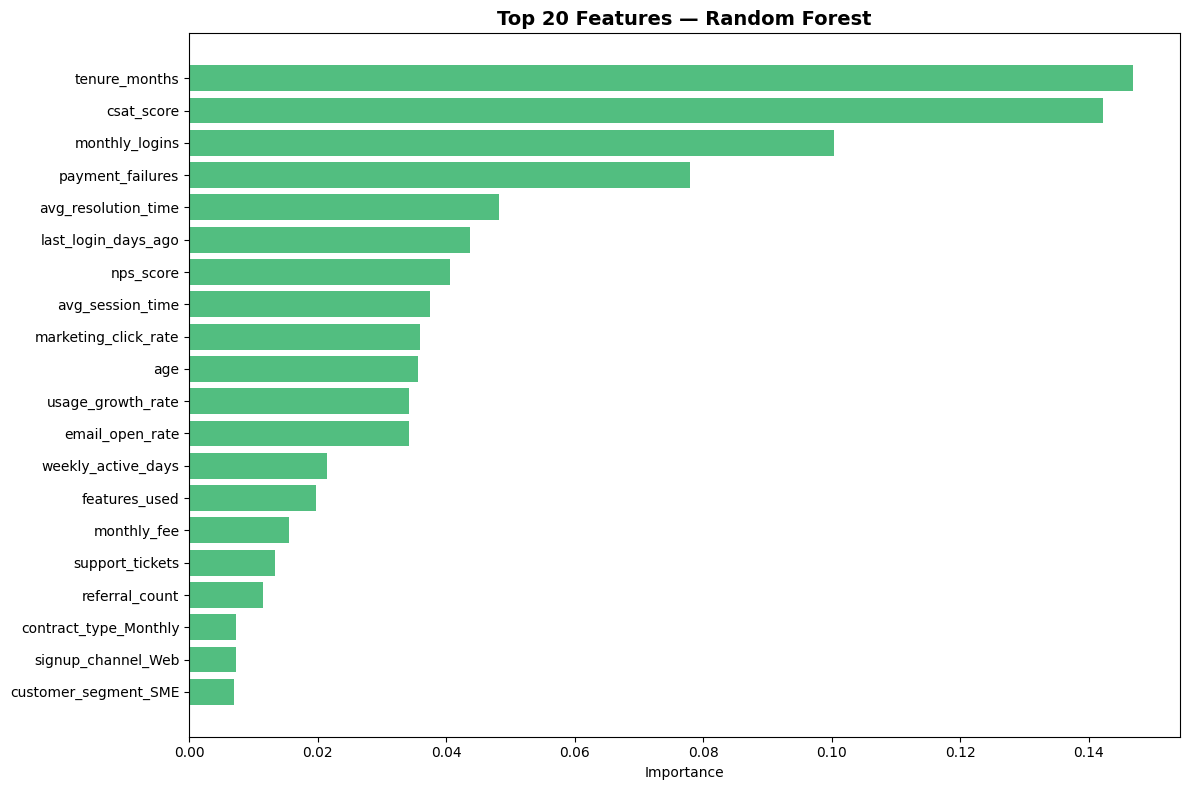


🔝 Top 10 features les plus importantes :
   1. tenure_months                       : 0.1469
   2. csat_score                          : 0.1423
   3. monthly_logins                      : 0.1004
   4. payment_failures                    : 0.0780
   5. avg_resolution_time                 : 0.0482
   6. last_login_days_ago                 : 0.0437
   7. nps_score                           : 0.0407
   8. avg_session_time                    : 0.0375
   9. marketing_click_rate                : 0.0359
   10. age                                 : 0.0356


In [11]:
# FEATURE IMPORTANCE

importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(12, 8))
plt.barh(range(20), 
         importances[indices][::-1],
         color='#27ae60', alpha=0.8)
plt.yticks(range(20), 
           [feature_names[i] for i in indices][::-1],
           fontsize=10)
plt.xlabel('Importance')
plt.title('Top 20 Features — Random Forest',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', dpi=150)
plt.show()

print("\n🔝 Top 10 features les plus importantes :")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]:35} : {importances[indices[i]]:.4f}")

## Tâche 2 — Régression du Revenu à Risque


## Vérification Anti-Data Leakage — Régression

Avant d'entraîner le modèle de régression, on vérifie que les données sont 
correctement préparées et qu'aucun data leakage n'est présent.

**Données de régression :**

| | Valeur |
|---|---|
| X_train_reg shape | (817, 50) — churners uniquement |
| y_train_reg_log shape | (817,) — log-transformé |
| y_train_reg_log min | 2.40 |
| y_train_reg_log max | 8.61 |
| y_test_reg shape | (2000,) — tous les clients |
| Zeros dans y_test_reg | 1796 (non-churners → revenue_at_risk = 0) |
| Churners dans y_test_reg | 204 (10.2%) |

**Contrôle anti-data leakage  :**
- `total_revenue` absent des features → **aucune fuite détectée**
- `revenue` absent des features → **aucune fuite détectée**

Ce contrôle est essentiel : `revenue_at_risk = total_revenue × churn`, donc 
conserver `total_revenue` comme feature introduirait un data leakage direct — 
le modèle prédirait la variable cible à partir d'une variable qui la compose.

**Log-transformation vérifiée :**
Les valeurs de y_train_reg_log (2.40 → 8.61) correspondent à des revenus 
réels de ~11€ à ~5500€ après `np.expm1()` — cohérent avec la distribution 
du dataset.

In [12]:
# VÉRIFICATION AVANT ENTRAÎNEMENT
X_train_reg     = np.load('../data/processed/X_train_reg.npy')
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')
y_test_reg      = np.load('../data/processed/y_test_reg.npy')

print("Vérification des données régression :")
print(f"  X_train_reg shape : {X_train_reg.shape}")
print(f"  y_train_reg_log shape : {y_train_reg_log.shape}")
print(f"  y_train_reg_log min : {y_train_reg_log.min():.2f}")
print(f"  y_train_reg_log max : {y_train_reg_log.max():.2f}")
print(f"  y_test_reg shape : {y_test_reg.shape}")
print(f"  y_test_reg — nb zeros : {(y_test_reg == 0).sum()}")
print(f"  y_test_reg — nb churners : {(y_test_reg > 0).sum()}")

# Vérifier que total_revenue n'est PAS dans X_train_reg
feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()
print(f"\n  Features contenant 'revenue' : {[f for f in feature_names if 'revenue' in f.lower()]}")
print(f"  Features contenant 'total' : {[f for f in feature_names if 'total' in f.lower()]}")

Vérification des données régression :
  X_train_reg shape : (817, 50)
  y_train_reg_log shape : (817,)
  y_train_reg_log min : 2.40
  y_train_reg_log max : 8.61
  y_test_reg shape : (2000,)
  y_test_reg — nb zeros : 1796
  y_test_reg — nb churners : 204

  Features contenant 'revenue' : []
  Features contenant 'total' : []


## Tâche 2 — Régression Random Forest (Revenu à Risque)

Le Random Forest Regressor est entraîné uniquement sur les **817 churners** du 
train set avec log-transformation de la variable cible, comme pour tous les 
modèles de régression.

**Hyperparamètres :**

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| n_estimators | 200 | Cohérent avec le classifieur |
| max_depth | 5 | Plus faible qu'en classification → évite l'overfitting sur 817 samples |
| min_samples_leaf | 20 | Régularisation forte adaptée au petit dataset |
| max_features | 0.5 | 50% des features par arbre → diversité des arbres |

**Résultats :**

| MAE | RMSE | R² |
|-----|------|----|
| 181.89 € | 434.38 € | 0.791 |

**Interprétation :**
Un R² de 0.791 signifie que le modèle explique **79.1%** de la variance du 
revenu à risque — bonne performance sur un dataset de seulement 817 churners.

La MAE de 181.89€ indique qu'en moyenne l'estimation du revenu à risque 
s'écarte de 182€ de la valeur réelle — acceptable pour un outil d'aide à 
la décision.

**Comparaison avec les autres modèles de régression :**

| Modèle | MAE | R² |
|--------|-----|----|
| XGBoost | **49.28 €** | **0.981** |
| **Random Forest** | **181.89 €** | **0.791** |
| Ridge | 330.91 € | 0.418 |
| MLP | 383.45 € | 0.159 |

Le Random Forest est 2ème en régression — largement surpassé par XGBoost 
mais bien meilleur que Ridge et MLP.

In [13]:
# TÂCHE 2 — RÉGRESSION Random Forest

X_train_reg     = np.load('../data/processed/X_train_reg.npy')
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')
y_test_reg      = np.load('../data/processed/y_test_reg.npy')
y_test_clf      = np.load('../data/processed/y_test_clf.npy')

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=20,
    max_features=0.5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg.fit(X_train_reg, y_train_reg_log)

y_pred_reg_log = rf_reg.predict(X_test)
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)

mask_test = y_test_clf == 1
mae  = mean_absolute_error(y_test_reg[mask_test], y_pred_reg[mask_test])
rmse = np.sqrt(mean_squared_error(y_test_reg[mask_test], y_pred_reg[mask_test]))
r2   = r2_score(y_test_reg[mask_test], y_pred_reg[mask_test])

print("Modèle de régression entraîné !")
print(f"\nRésultats — Random Forest Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

Résultats — Random Forest Regression (churners uniquement)
   MAE  : 181.89 €
   RMSE : 434.38 €
   R²   : 0.7911


In [14]:
import time
import os

# SAUVEGARDE — seuil 0.5 (Recall maximal)
y_pred_clf  = (y_proba_under >= best_t).astype(int)
y_proba_clf = y_proba_under

# Mesure temps entraînement
start = time.time()
rf_clf.fit(X_train_under, y_train_clf_under)
temps_rf_clf = time.time() - start

start = time.time()
rf_reg.fit(X_train_reg, y_train_reg_log)  # ← corrigé
temps_rf_reg = time.time() - start

print(f"Sauvegarde du modèle : {best_technique}")
joblib.dump(rf_clf, '../models/rf_classification.pkl')
joblib.dump(rf_reg, '../models/rf_regression.pkl')

results_clf = {
    'model'    : 'Random Forest (' + best_technique + ')',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf),
    'pr_auc'   : average_precision_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'Random Forest Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/rf_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/rf_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\n=== ÉCORESPONSABILITÉ ===")
print(f"Temps RF classification  : {temps_rf_clf:.3f}s")
print(f"Temps RF régression      : {temps_rf_reg:.3f}s")
print(f"Taille RF clf  : {os.path.getsize('../models/rf_classification.pkl')/1024:.1f} KB")
print(f"Taille RF reg  : {os.path.getsize('../models/rf_regression.pkl')/1024:.1f} KB")

print(f"\nRésumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")
print(f"\nRésumé Régression :")
for k, v in results_reg.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Sauvegarde du modèle : Undersampling
Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

=== ÉCORESPONSABILITÉ ===
Temps RF classification  : 0.303s
Temps RF régression      : 0.217s
Taille RF clf  : 3196.4 KB
Taille RF reg  : 526.0 KB

Résumé Classification :
   accuracy   : 0.6955
   precision  : 0.2339
   recall     : 0.8725
   f1         : 0.3689
   roc_auc    : 0.8024
   pr_auc     : 0.2974

Résumé Régression :
   mae        : 181.8914
   rmse       : 434.3811
   r2         : 0.7911


## Synthèse — Random Forest

Le Random Forest constitue une nette amélioration par rapport au modèle baseline. 
L'undersampling a été retenu (Recall=0.848 vs 0.137 pour SMOTE), ce qui s'explique 
par la sensibilité des forêts d'arbres aux données synthétiques — le RF overfitte 
sur les churners SMOTE et ne généralise pas sur les vrais churners.

**Tâche 1 — Classification :** Le modèle final atteint un **Recall de 0.873** 
avec le seuil optimisé de 0.45, détectant **178 churners sur 204** (vs 173 avec 
seuil 0.5). Le seuil 0.45 protège 5 churners supplémentaires = **4 225€ de revenu 
supplémentaire** pour seulement 41 fausses alarmes de plus. La validation croisée 
(Recall = 0.845 ± 0.030 à seuil=0.5, 0.869 ± 0.027 à seuil=0.45) confirme la 
stabilité sans surapprentissage — les écarts-types les plus faibles du projet.

**Tâche 2 — Régression :** MAE = 181.89€, RMSE = 434.38€, R² = 0.791 — 
nettement meilleur que la Ridge baseline (330.91€) et le MLP (383.45€).

**Limites :** La Precision reste faible (0.234 à seuil=0.45), générant 583 fausses 
alarmes. Le modèle est peu interprétable mais la feature importance 
(tenure_months, csat_score, monthly_logins) compense partiellement en 
fournissant une explication globale des prédictions.

In [15]:
# Vérification surapprentissage — train vs test
y_pred_train = rf_clf.predict(X_train_under)
recall_train = recall_score(y_train_clf_under, y_pred_train)
recall_test  = recall_score(y_test_clf, y_pred_clf)

print(f"Recall TRAIN : {recall_train:.4f}")
print(f"Recall TEST  : {recall_test:.4f}")
print(f"Écart        : {abs(recall_train - recall_test):.4f}")

Recall TRAIN : 0.8898
Recall TEST  : 0.8725
Écart        : 0.0173
